In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import os
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import duckdb
load_dotenv()

True

In [2]:
os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("AWS_USER", "")
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("AWS_PASSWORD", "")
os.environ["AWS_DEFAULT_REGION"] = "us-east-1"

con = duckdb.connect()

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

con.execute("SET s3_region='us-east-1';")

In [3]:
df = con.execute("""
    SELECT 
        f.date,
        f.hour,
        AVG(f.aqi) as avg_aqi
    FROM read_parquet(
        's3://stream-analytics-project-bucket/gold/airnow/fact_air_quality_readings/*/*/*.parquet'
    ) f
    JOIN read_parquet(
        's3://stream-analytics-project-bucket/gold/airnow/dim_parameter/*.parquet'
    ) p 
    ON f.parameter_key = p.parameter_key
    WHERE f.date BETWEEN '2025-12-30' AND '2026-01-05'
      AND p.parameter = 'PM2.5'
    GROUP BY f.date, f.hour
    ORDER BY f.date, f.hour
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [4]:
df["datetime_utc"] = (
    pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="h")
)
df["datetime_est"] = (
    df["datetime_utc"]
    .dt.tz_localize("UTC")          # mark as UTC
    .dt.tz_convert("US/Eastern")    # convert to Eastern Time
)

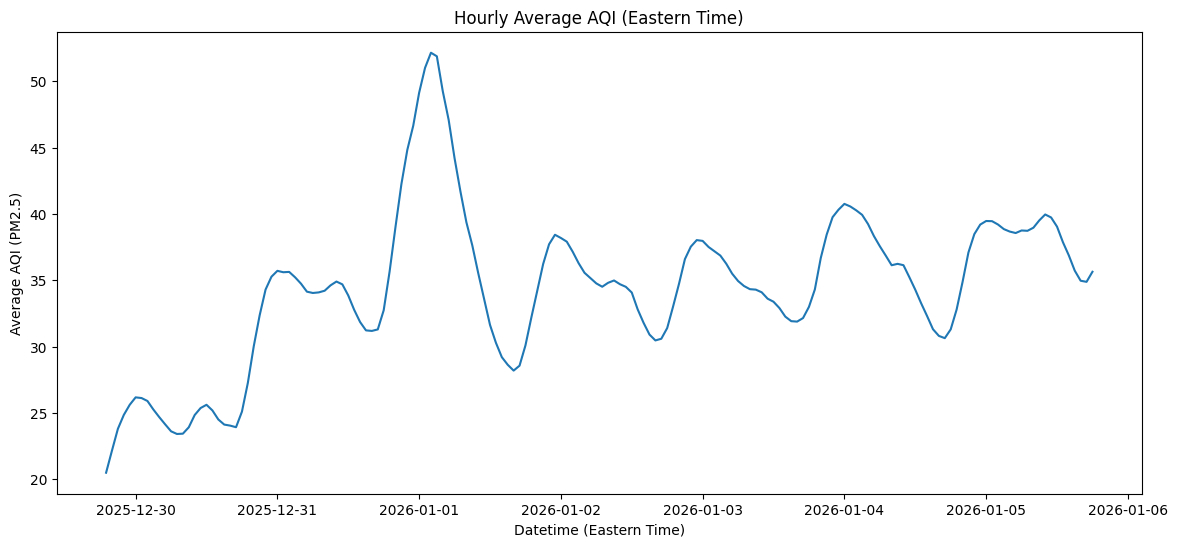

In [22]:
plt.figure(figsize=(14, 6))
plt.plot(df["datetime_est"], df["avg_aqi"])

plt.xlabel("Datetime (Eastern Time)")
plt.ylabel("Average AQI (PM2.5)")
plt.title("Hourly Average AQI (Eastern Time)")

# plt.xticks(rotation=45)
# plt.tight_layout()

plt.show()

In [6]:
# Assuming you've already created datetime_est as shown earlier

filtered_df = df[
    (df["datetime_est"] >= "2025-12-31 00:00:00") &
    (df["datetime_est"] <= "2026-01-01 23:59:59")
].copy()

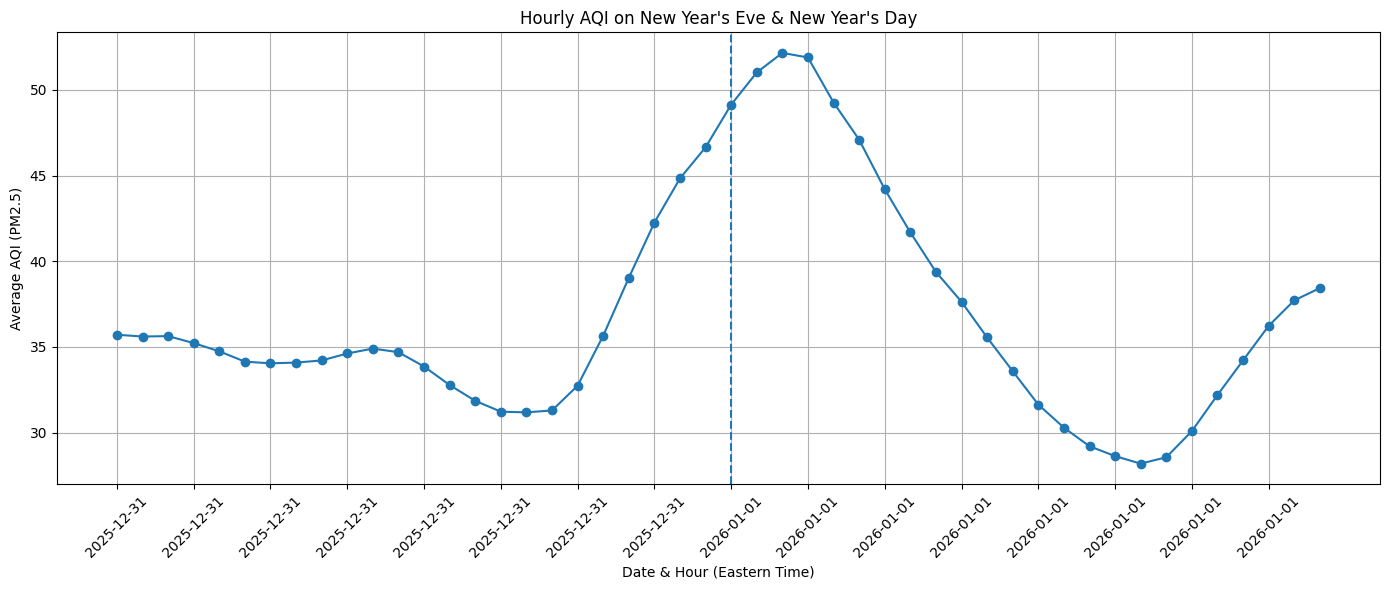

In [28]:


plt.figure(figsize=(14, 6))
plt.plot(filtered_df["datetime_est"], filtered_df["avg_aqi"], marker='o')

plt.xlabel("Date & Hour (Eastern Time)")
plt.ylabel("Average AQI (PM2.5)")
plt.title("Hourly AQI on New Year's Eve & New Year's Day")
plt.axvline(pd.Timestamp("2026-01-01 00:00:00", tz="US/Eastern"), linestyle="--") # type: ignore

plt.xticks(filtered_df["datetime_est"][::3], rotation=45)  # every 3 hours
plt.grid(True)
plt.tight_layout()

plt.show()

In [8]:
region_df = con.execute("""
    SELECT 
        f.date,
        f.hour,
        s.latitude,
        s.longitude,         
        AVG(f.aqi) as avg_aqi
    FROM read_parquet(
        's3://stream-analytics-project-bucket/gold/airnow/fact_air_quality_readings/*/*/*.parquet'
    ) f
    JOIN read_parquet(
        's3://stream-analytics-project-bucket/gold/airnow/dim_parameter/*.parquet'
    ) p
    ON f.parameter_key = p.parameter_key
    JOIN read_parquet(
        's3://stream-analytics-project-bucket/gold/airnow/dim_site/*.parquet'
    ) s
    ON f.site_key = s.site_key
    WHERE f.date BETWEEN '2025-12-30' AND '2026-01-05'
      AND p.parameter = 'PM2.5'
    GROUP BY f.date, f.hour, s.latitude, s.longitude
    ORDER BY f.date, f.hour
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [9]:
region_df["datetime_utc"] = (
    pd.to_datetime(region_df["date"]) + pd.to_timedelta(region_df["hour"], unit="h")
)
region_df["datetime_est"] = (
    region_df["datetime_utc"]
    .dt.tz_localize("UTC")          # mark as UTC
    .dt.tz_convert("US/Eastern")    # convert to Eastern Time
)

In [10]:
filtered_region_df = region_df[
    (region_df["datetime_est"] >= "2025-12-31 00:00:00") &
    (region_df["datetime_est"] <= "2026-01-01 23:59:59")
].copy()

In [11]:
US_REGIONS = {
    "Northeast": {"lat_min": 36.5, "lat_max": 47.5, "lon_min": -80,  "lon_max": -66},
    "Midwest":   {"lat_min": 36.5, "lat_max": 49.5, "lon_min": -104, "lon_max": -80},
    "South":     {"lat_min": 25,   "lat_max": 36.5, "lon_min": -105, "lon_max": -75},
    "West":      {"lat_min": 31,   "lat_max": 49.5, "lon_min": -125, "lon_max": -104},
    "Alaska":    {"lat_min": 51,   "lat_max": 71,   "lon_min": -170, "lon_max": -130},
    "Hawaii":    {"lat_min": 18.5, "lat_max": 22.5, "lon_min": -161, "lon_max": -154}
}
def assign_region(lat, lon):
    for region, bounds in US_REGIONS.items():
        if (
            bounds["lat_min"] <= lat <= bounds["lat_max"]
            and bounds["lon_min"] <= lon <= bounds["lon_max"]
        ):
            return region
    return "Other"

In [12]:
filtered_region_df["region"] = filtered_region_df.apply(
    lambda r: assign_region(r.latitude, r.longitude),
    axis=1
)
grouped = (
    filtered_region_df.groupby(["datetime_est", "region"])["avg_aqi"]
    .mean()
    .reset_index()
)
reg_filtered = grouped[
    (grouped["datetime_est"] >= "2025-12-31 00:00:00") &
    (grouped["datetime_est"] <= "2026-01-01 23:59:59")
].copy()

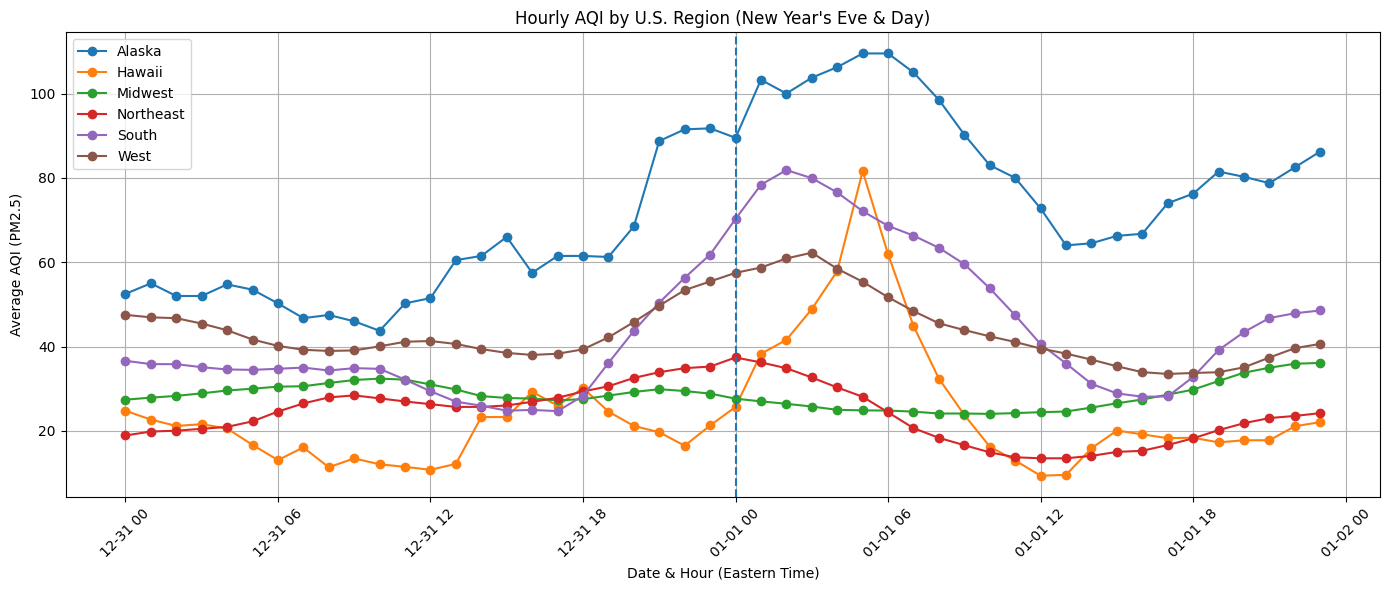

In [ ]:
plt.figure(figsize=(14, 6))

for region in reg_filtered["region"].unique():
    re_region_df = reg_filtered[reg_filtered["region"] == region]
    
    plt.plot(
        re_region_df["datetime_est"],
        re_region_df["avg_aqi"],
        marker='o',
        label=region
    )

plt.xlabel("Date & 24-Hour (Eastern Time)")
plt.ylabel("Average AQI (PM2.5)")
plt.title("Hourly AQI by U.S. Region (New Year's Eve & Day)")
plt.axvline(pd.Timestamp("2026-01-01 00:00:00", tz="US/Eastern"), linestyle="--") # type: ignore

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()